# Multiple Variable Linear Regression

## Goals
Extend the regression model to support multiple features instead of just one, and use np.dot to vectorize predictions, cost, and gradient calculations.

In [2]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)

## Problem Statement

Training data with 3 examples and 4 features each: size (sqft), bedrooms, floors, and age. Unlike previous labs, size is in raw sqft, not thousands.

In [3]:
x_train = np.array([[2104,5,1,45],
                    [1410,3,2,45],
                    [852, 2, 1, 35]])
y_train = np.array([460,232,178])

Display the input data.

## Parameter vector w, b

w is now a vector with one element per feature (4 elements). b is still a single scalar.

In [4]:
b_init = 785.1811367994083
w_init = np.array([0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


## Model Prediction With Multiple Variables

The prediction formula is now: f(x) = w0*x0 + w1*x1 + w2*x2 + w3*x3 + b

Let's first implement this the "slow way" - looping through each feature one at a time.

In [5]:
def predict_singleloop(x,w,b):
    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = x[i]*w[i]
        p = p+p_i
    p = p+b
    return p

In [6]:
x_vec = x_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

f_wb = predict_singleloop(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


### Single Prediction, vector

Equation (1) can be rewritten as a dot product. Instead of looping through each feature manually, np.dot does it all at once.

In [7]:
def predict(x,w,b):
    p = np.dot(x,w)+b
    return p

In [8]:
x_vec = x_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

f_wb = predict(x_vec,w_init,b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


## Compute Cost With Multiple Variables

The cost function formula stays the same as before - only difference is w and x are now vectors instead of scalars.

In [9]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost = cost + (f_wb_i - y[i])**2
    cost = cost / (2 * m)
    return cost

In [10]:
cost = compute_cost(x_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 3013.0063362127967


## Compute gradient With Multiple Variables

Now we need a gradient for each individual weight (one per feature), plus one gradient for b. This means an extra loop - one for examples, one for features.

In [17]:
def compute_gradient(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] +=  err * X[i, j]
        dj_db =  err
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_db, dj_dw

In [14]:
tmp_dj_db, tmp_dj_dw = compute_gradient(x_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -44.818199340591754
dj_dw at initial w,b: 
 [-63193.66   -134.45    -89.64  -2016.82]


## Gradient Descent With Multiple Variables

Same overall structure as before - the difference is w gets updated as a whole vector at once, and we use copy.deepcopy to avoid accidentally modifying the original w_init.

In [33]:
def gradient_descent(x,y,w_in,b_in,cost_fucntion,gradient_fucntion,num_iters,alpha):
    j_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_db,dj_dw = gradient_fucntion(x,y,w,b)

        w = w-alpha*dj_dw
        b = b-alpha*dj_db

        if i<100000:
            j_history.append(cost_fucntion(x,y,w,b))

        if i % math.ceil(num_iters/10) ==0 :
            print(f"iteration  {i:4d}: cost  {j_history[-1]:8.2f}")

    return w,b,j_history
        
    

Now let's actually run gradient descent on the multi-feature house data.


In [42]:
initial_w = np.zeros_like(w_init)
initial_b = 0.

iteration = 1000
alpha = 5.0e-7

w_final, b_final, j_history = gradient_descent(x_train, y_train, initial_w, initial_b,
                                                  compute_cost, compute_gradient,
                                                  iteration, alpha)

print(f"b,w found by gradient descent: {b_final:0.2f},{w_final}")


m,_ = x_train.shape
for i in range(m):
    print(f"prediction: {np.dot(x_train[i],w_final)+b_final:0.2f}  target value : {y_train[i]} ")


iteration     0: cost   2456.91
iteration   100: cost    672.89
iteration   200: cost    670.13
iteration   300: cost    667.40
iteration   400: cost    664.70
iteration   500: cost    662.03
iteration   600: cost    659.39
iteration   700: cost    656.78
iteration   800: cost    654.19
iteration   900: cost    651.64
b,w found by gradient descent: 0.00,[ 0.21  0.   -0.01 -0.11]
prediction: 427.37  target value : 460 
prediction: 284.77  target value : 232 
prediction: 171.22  target value : 178 


### Cost versus iterations of gradient descent

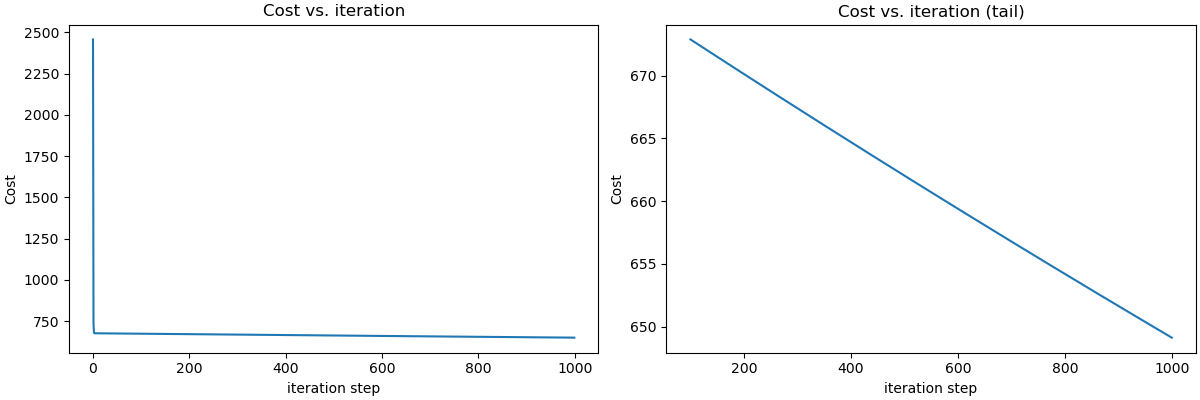

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(j_history)
ax2.plot(100 + np.arange(len(j_history[100:])), j_history[100:])
ax1.set_title("Cost vs. iteration")
ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')
ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')
ax2.set_xlabel('iteration step')
plt.savefig("cost_vs_iteration_multi.png")
plt.close()

from IPython.display import Image
Image("cost_vs_iteration_multi.png")

## Summary
Extended linear regression to support multiple features - rewrote prediction, cost, and gradient functions to work with vectors/matrices using np.dot. Confirmed that raw feature scales (like sqft vs floor count) cause gradient descent to need a very small learning rate - next lab covers feature scaling to fix this.